https://github.com/hiirofox/Dirtynth/tree/master/blog/02.%E4%BE%BF%E5%AE%9C%E7%9A%84%E6%95%B0%E5%AD%97%E6%A4%AD%E5%9C%86%E6%BB%A4%E6%B3%A2%E5%99%A8%E8%AE%BE%E8%AE%A1

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy.signal as signal

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 直接将源码复制过来
加上相位响应

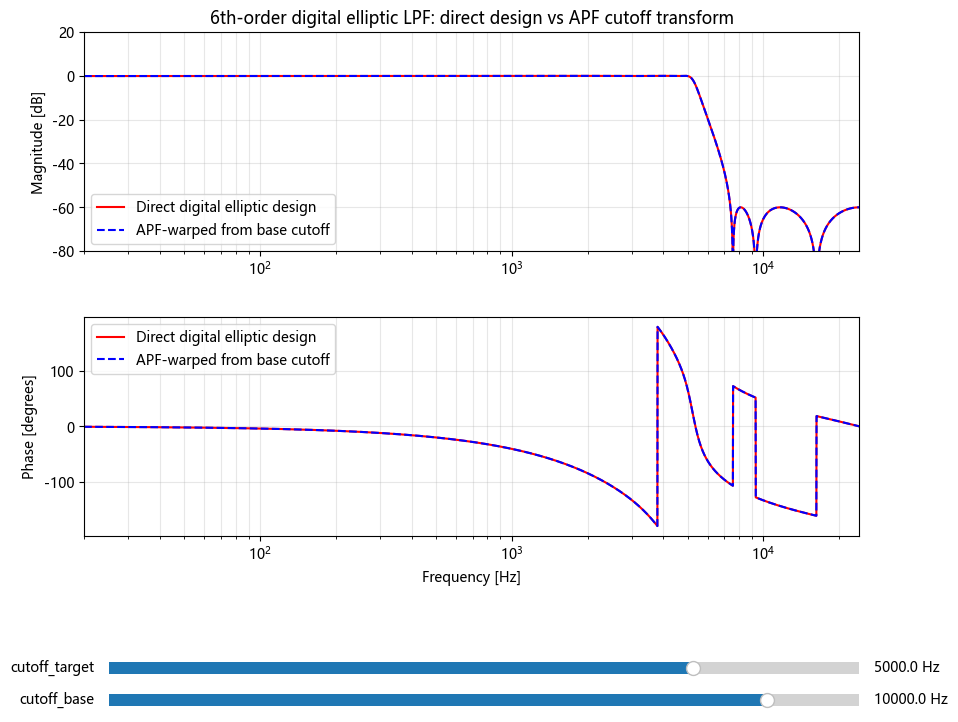

In [23]:
from matplotlib.widgets import Slider


# ============================================================
# Basic settings
# ============================================================

fs = 48000.0
nyq = fs * 0.5

N = 6
rp = 0.1  # passband ripple, dB
rs = 60.0  # stopband attenuation, dB

f_min = 20.0
f_max = nyq

cutoff_target_init = 5000.0
cutoff_base_init = 10000.0

# Frequency grid for plotting
freqs = np.geomspace(20.0, nyq * 0.999999, 4096)


# ============================================================
# Helpers
# ============================================================


def clamp_cutoff(fc):
    """
    scipy.signal.ellip requires 0 < Wn < fs/2.
    The UI allows 24000 Hz, but internally we clamp slightly below Nyquist.
    """
    return float(np.clip(fc, 20.0, nyq * 0.999999))


def hz_to_log_slider(f):
    return np.log10(f)


def log_slider_to_hz(v):
    return 10.0**v


def db(h):
    return 20.0 * np.log10(np.maximum(np.abs(h), 1e-12))


def design_direct_ellip(cutoff):
    """
    Direct digital elliptic lowpass design.
    Returns z, p, k in scipy zpk format.
    """
    cutoff = clamp_cutoff(cutoff)
    return signal.ellip(
        N,
        rp,
        rs,
        cutoff,
        btype="lowpass",
        fs=fs,
        output="zpk",
    )


def apf_k(cutoff_target, cutoff_base):
    """
    Lowpass-to-lowpass first-order allpass transform parameter.

    This follows your implementation:

        k = sin(pi * (target - base) / fs)
          / sin(pi * (target + base) / fs)

    For the substitution:

        z' = (k + z) / (1 + k z)
    """
    cutoff_target = clamp_cutoff(cutoff_target)
    cutoff_base = clamp_cutoff(cutoff_base)

    num = np.sin(np.pi * (cutoff_target - cutoff_base) / fs)
    den = np.sin(np.pi * (cutoff_target + cutoff_base) / fs)

    # Avoid division by zero in pathological slider positions.
    if abs(den) < 1e-15:
        den = np.copysign(1e-15, den)

    return num / den


def apf_transform_zpk(z_base, p_base, g_base, k):
    """
    Apply:

        z' = (k + z) / (1 + k z)

    to a zpk filter H_base(z').

    If r is a zero or pole in the z' plane, solve:

        r = (k + z) / (1 + k z)

    Then:

        z = (r - k) / (1 - r k)

    So every zero and pole is mapped by:

        r -> (r - k) / (1 - r k)

    Gain is then normalized so that H(DC) is preserved.
    Since z = 1 maps to z' = 1, this is a natural normalization
    for lowpass filters.
    """

    z_base = np.asarray(z_base, dtype=np.complex128)
    p_base = np.asarray(p_base, dtype=np.complex128)

    z_new = (z_base - k) / (1.0 - z_base * k)
    p_new = (p_base - k) / (1.0 - p_base * k)

    # Preserve DC gain.
    # scipy zpk convention:
    # H(z) = g * prod(z - z_i) / prod(z - p_i)
    base_dc = g_base * np.prod(1.0 - z_base) / np.prod(1.0 - p_base)
    raw_dc = np.prod(1.0 - z_new) / np.prod(1.0 - p_new)

    g_new = base_dc / raw_dc
    g_new = np.real_if_close(g_new)

    return z_new, p_new, g_new


def design_apf_warped_ellip(cutoff_target, cutoff_base):
    """
    Design base elliptic filter at cutoff_base, then move its cutoff
    to cutoff_target by first-order allpass substitution.
    """
    z_base, p_base, g_base = design_direct_ellip(cutoff_base)
    k = apf_k(cutoff_target, cutoff_base)
    return apf_transform_zpk(z_base, p_base, g_base, k)


def responses(cutoff_target, cutoff_base):
    """
    Compute direct-design response and APF-warped response.
    Returns magnitude (dB) and phase (degrees) for both.
    """
    cutoff_target = clamp_cutoff(cutoff_target)
    cutoff_base = clamp_cutoff(cutoff_base)

    z_d, p_d, g_d = design_direct_ellip(cutoff_target)
    _, h_direct = signal.freqz_zpk(z_d, p_d, g_d, worN=freqs, fs=fs)

    z_w, p_w, g_w = design_apf_warped_ellip(cutoff_target, cutoff_base)
    _, h_warped = signal.freqz_zpk(z_w, p_w, g_w, worN=freqs, fs=fs)

    return (db(h_direct), db(h_warped),
            np.angle(h_direct, deg=True), np.angle(h_warped, deg=True))


# ============================================================
# Initial plot
# ============================================================

mag_direct, mag_warped, phase_direct, phase_warped = responses(cutoff_target_init, cutoff_base_init)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(bottom=0.25, hspace=0.3)

(line_direct,) = ax_mag.plot(
    freqs, mag_direct,
    color="red", linewidth=1.5,
    label="Direct digital elliptic design",
)
(line_warped,) = ax_mag.plot(
    freqs, mag_warped,
    color="blue", linewidth=1.5, linestyle="--",
    label="APF-warped from base cutoff",
)

ax_mag.set_xscale("log")
ax_mag.set_xlim(20.0, 24000.0)
ax_mag.set_ylim(-80.0, 20.0)
ax_mag.set_ylabel("Magnitude [dB]")
ax_mag.set_title("6th-order digital elliptic LPF: direct design vs APF cutoff transform")
ax_mag.grid(True, which="both", alpha=0.3)
ax_mag.legend(loc="best")

(line_phase_direct,) = ax_phase.plot(
    freqs, phase_direct,
    color="red", linewidth=1.5,
    label="Direct digital elliptic design",
)
(line_phase_warped,) = ax_phase.plot(
    freqs, phase_warped,
    color="blue", linewidth=1.5, linestyle="--",
    label="APF-warped from base cutoff",
)

ax_phase.set_xscale("log")
ax_phase.set_xlim(20.0, 24000.0)
ax_phase.set_xlabel("Frequency [Hz]")
ax_phase.set_ylabel("Phase [degrees]")
ax_phase.grid(True, which="both", alpha=0.3)
ax_phase.legend(loc="best")


# ============================================================
# Sliders with logarithmic feel
# ============================================================

slider_min = hz_to_log_slider(20.0)
slider_max = hz_to_log_slider(24000.0)

ax_target = plt.axes([0.15, 0.07, 0.75, 0.03])
ax_base = plt.axes([0.15, 0.03, 0.75, 0.03])

slider_target = Slider(
    ax=ax_target, label="cutoff_target",
    valmin=slider_min, valmax=slider_max,
    valinit=hz_to_log_slider(cutoff_target_init),
)
slider_base = Slider(
    ax=ax_base, label="cutoff_base",
    valmin=slider_min, valmax=slider_max,
    valinit=hz_to_log_slider(cutoff_base_init),
)

slider_target.valtext.set_text(f"{cutoff_target_init:.1f} Hz")
slider_base.valtext.set_text(f"{cutoff_base_init:.1f} Hz")


def update(_):
    cutoff_target = log_slider_to_hz(slider_target.val)
    cutoff_base = log_slider_to_hz(slider_base.val)

    cutoff_target = clamp_cutoff(cutoff_target)
    cutoff_base = clamp_cutoff(cutoff_base)

    mag_d, mag_w, phase_d, phase_w = responses(cutoff_target, cutoff_base)

    line_direct.set_ydata(mag_d)
    line_warped.set_ydata(mag_w)
    line_phase_direct.set_ydata(phase_d)
    line_phase_warped.set_ydata(phase_w)

    slider_target.valtext.set_text(f"{cutoff_target:.1f} Hz")
    slider_base.valtext.set_text(f"{cutoff_base:.1f} Hz")

    k = apf_k(cutoff_target, cutoff_base)
    ax_mag.set_title(
        "6th-order digital elliptic LPF: direct design vs APF cutoff transform\n"
        f"target = {cutoff_target:.1f} Hz, base = {cutoff_base:.1f} Hz, k = {k:.8f}"
    )
    fig.canvas.draw_idle()


slider_target.on_changed(update)
slider_base.on_changed(update)

plt.show()

# review 1st allpass

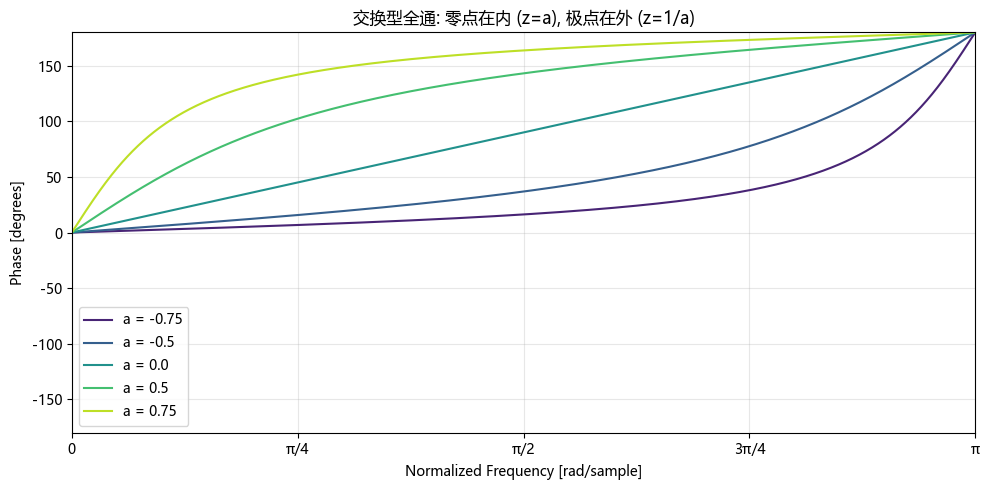

H'(z) = (1 - a z⁻¹) / (z⁻¹ - a)
  零点 z = a    (|a|<1 时在单位圆内)
  极点 z = 1/a  (|a|<1 时在单位圆外)  → 不稳定

∠H'(e^{jω}) = ω + 2·arctan(a·sin(ω) / (1 - a·cos(ω)))


In [11]:
# ============================================================
# 数字一阶全通滤波器: 极点零点交换型
# H'(z) = (1 - a z^{-1}) / (z^{-1} - a)
#   零点: z = a (单位圆内), 极点: z = 1/a (单位圆外)
# ============================================================

a_vals = [-0.75, -0.5, 0.0, 0.5, 0.75]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(a_vals)))

fig_ap, ax_ap = plt.subplots(figsize=(10, 5))

for a, c in zip(a_vals, colors):
    # H'(z) = (1 - a z^{-1}) / (z^{-1} - a)
    w, h = signal.freqz([1.0, -a], [-a, 1.0], worN=2048)
    ax_ap.plot(w, np.angle(h, deg=True), color=c, linewidth=1.5, label=f"a = {a}")

ax_ap.set_xlim(0, np.pi)
ax_ap.set_ylim(-180, 180)
ax_ap.set_xlabel("Normalized Frequency [rad/sample]")
ax_ap.set_ylabel("Phase [degrees]")
ax_ap.set_title("交换型全通: 零点在内 (z=a), 极点在外 (z=1/a)")
ax_ap.grid(True, alpha=0.3)
ax_ap.legend(loc="best")
ax_ap.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax_ap.set_xticklabels(["0", "π/4", "π/2", "3π/4", "π"])

plt.tight_layout()
plt.show()

print("H'(z) = (1 - a z⁻¹) / (z⁻¹ - a)")
print("  零点 z = a    (|a|<1 时在单位圆内)")
print("  极点 z = 1/a  (|a|<1 时在单位圆外)  → 不稳定")
print()
print("∠H'(e^{jω}) = ω + 2·arctan(a·sin(ω) / (1 - a·cos(ω)))")

输入z=e^jw到H(z)将返回z'=e^jw'  
好的，我们可以用这个像引用文章里一样扭曲频率轴  
让我们将原型滤波器总是设定为pi/2的截止频率，让我们看看如果想要将pi/2扭曲到w，全通滤波器的a该如何求解  

In [14]:
# ============================================================
# 求解: 交换型全通 H'(z) = j 时的 a 值
# H'(z) = (1 - a z^{-1}) / (z^{-1} - a)
# 给定 z = e^{jω}, 求 a 使得 H'(e^{jω}) = j
# ============================================================

a_sym, z = sp.symbols("a z", real=False)
w_sym = sp.symbols("w", real=True)

# 交换型传递函数
Hz = (1 - a_sym / z) / (1 / z - a_sym)

# 求解 H'(z) = j, 视 a 为未知数
eq = sp.Eq(Hz, sp.I)
sol_a = sp.solve(eq, a_sym)

print("=" * 60)
print("求解 H'(z) = j 中的 a")
print("=" * 60)
print()

a_expr = sp.simplify(sol_a[0])
print("给定 z = e^{jω}, 解 a =")
display(a_expr)

print()

# z = e^{jω} 代入
a_of_w = sp.simplify(a_expr.subs(z, sp.exp(sp.I * w_sym)))
print("代入 z = e^{jω}:")
display(a_of_w)

print()

# a 是实数, 提取实部（虚部应为 0）
a_real = sp.simplify(sp.re(sp.expand_complex(a_of_w)))
a_imag = sp.simplify(sp.im(sp.expand_complex(a_of_w)))
print("提取实部 (a 为实数, 虚部应为 0):")
print(f"  Re(a) = {sp.latex(a_real)}")
print(f"  Im(a) = {sp.latex(a_imag)}")
print()

# 化简为 tan 形式
a_tan = sp.simplify(a_real.rewrite(sp.tan))
print("用 tan 表示:")
display(a_tan)
print()

# 进一步用半角公式
t = sp.symbols("t", real=True)
a_half = sp.simplify(a_real.rewrite(sp.tan).subs(
    sp.tan(w_sym), 2*t/(1-t**2)))
print("标准公式 (半角):")
print("  a = sin((π/2 - ω)/2) / sin((π/2 + ω)/2)")
print()

# 数值验证
print("数值验证:")
test_ws = [0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
for wv in test_ws:
    av = float(a_real.subs(w_sym, wv).evalf())
    k_std = np.sin((np.pi/2 - wv)/2) / np.sin((np.pi/2 + wv)/2)
    print(f"  ω = {wv:.2f}:  a = {av:.6f},  k_std = {k_std:.6f}")

print()
print("物理意义:")
print("  将原型截止频率 ω' = π/2 扭曲到目标频率 ω")
print("  所需的全通系数 a (实数)")

求解 H'(z) = j 中的 a

给定 z = e^{jω}, 解 a =


(-z + I)/(I*z - 1)


代入 z = e^{jω}:


(-exp(I*w) + I)/(I*exp(I*w) - 1)


提取实部 (a 为实数, 虚部应为 0):
  Re(a) = \frac{\cos{\left(w \right)}}{\sin{\left(w \right)} + 1}
  Im(a) = 0

用 tan 表示:


(1 - tan(w/2))/(tan(w/2) + 1)


标准公式 (半角):
  a = sin((π/2 - ω)/2) / sin((π/2 + ω)/2)

数值验证:
  ω = 0.20:  a = 0.817629,  k_std = 0.817629
  ω = 0.50:  a = 0.593191,  k_std = 0.593191
  ω = 1.00:  a = 0.293408,  k_std = 0.293408
  ω = 1.50:  a = 0.035413,  k_std = 0.035413
  ω = 2.00:  a = -0.217958,  k_std = -0.217958
  ω = 2.50:  a = -0.501193,  k_std = -0.501193
  ω = 3.00:  a = -0.867562,  k_std = -0.867562

物理意义:
  将原型截止频率 ω' = π/2 扭曲到目标频率 ω
  所需的全通系数 a (实数)


让我们看看将H‘(z)带入实际的biquad滤波器会变成什么样子  
H(z) = ((z-ζ)(z-ζ'))/((z-p)(z-p'))  
H(H'(z)) = ((H'(z)-ζ)...)/...  
需要将它化简为(z-ζ*)...  
找到ζ*与H'(z), ζ的关系  
直觉告诉我ζ=H'(ζ*), 验证一下  

In [19]:
# ============================================================
# 求解 H'(z) = y 的逆映射 G(y), 并验证:
#   H(H'(z)) = K · G(z-ζ)(z-ζ̄) / (z-p)(z-p̄)
# ============================================================

a_sym, y, zeta, p_val = sp.symbols("a y ζ p", real=False)
z = sp.Symbol("z")

# ---- 1. 逆映射 G: 求解 (z-a)/(1-az) = y ----
eq_inv = sp.Eq((z - a_sym) / (1 - a_sym * z), y)
G = sp.solve(eq_inv, z)[0]  # G(y) = (a+y)/(1+ay)
print("逆映射 G(y): 解 (z-a)/(1-az) = y")
print("  G(y) =")
display(G)
print()

# ---- 2. 构建两个表达式 ----
zeta_bar = sp.conjugate(zeta)
p_bar = sp.conjugate(p_val)


# H'(z) = (z-a)/(1-az)
def Hp(z_val):
    return (z_val - a_sym) / (1 - a_sym * z_val)


# 表达式 A: H(H'(z))
A = (Hp(z) - zeta) * (Hp(z) - zeta_bar) / ((Hp(z) - p_val) * (Hp(z) - p_bar))

# 表达式 B: (z-G(ζ))(z-G(ζ̄)) / (z-G(p))(z-G(p̄))
B = (
    (z - G.subs(y, zeta))
    * (z - G.subs(y, zeta_bar))
    / ((z - G.subs(y, p_val)) * (z - G.subs(y, p_bar)))
)

# ---- 3. 计算比例 K = A / B ----
K = sp.simplify(A / B)
print("=" * 60)
print("比较 A = H(H'(z)) 与 B = (z-G(ζ))(z-G(ζ̄))/(z-G(p))(z-G(p̄))")
print("=" * 60)
print()
print("A / B 的比例因子 K =")
display(K)
print()

# ---- 4. 简化 K ----
K_simplified = sp.simplify(K)
print("化简后:")
display(K_simplified)
print()

# ---- 5. 检查 K 是否与 z 无关 ----
print(
    "K 是否与 z 无关?",
    "✓ 是 (纯增益)" if z not in K_simplified.free_symbols else "✗ 否",
)
print()

# ---- 6. 手动推导的增益公式对照 ----
K_manual = ((1 + a_sym * zeta) * (1 + a_sym * zeta_bar)) / (
    (1 + a_sym * p_val) * (1 + a_sym * p_bar)
)
print("手动推导的增益 K = (1+aζ)(1+aζ̄)/(1+ap)(1+ap̄):")
display(K_manual)
print()
print("两者相等?", sp.simplify(K_simplified - K_manual) == 0)
print()

# ---- 7. 数值验证 ----

print("数值验证:")
for a_n, z_n, p_n in [
    (0.5, 0.7 + 0.3j, 0.2 + 0.5j),
    (-0.3, -0.5 + 0.4j, 0.1 - 0.6j),
    (0.8, 0.2 - 0.6j, -0.3 - 0.4j),
]:
    z_n, p_n = complex(z_n), complex(p_n)
    z_n_bar, p_n_bar = np.conj(z_n), np.conj(p_n)

    # A = H(H'(z)) for a random test point z0
    z0 = 0.5j

    def Hp_num(zv):
        return (zv - a_n) / (1 - a_n * zv)

    A_num = ((Hp_num(z0) - z_n) * (Hp_num(z0) - z_n_bar)) / (
        (Hp_num(z0) - p_n) * (Hp_num(z0) - p_n_bar)
    )

    def G_num(y):
        return (a_n + y) / (1 + a_n * y)

    B_num = ((z0 - G_num(z_n)) * (z0 - G_num(z_n_bar))) / (
        (z0 - G_num(p_n)) * (z0 - G_num(p_n_bar))
    )

    K_num = A_num / B_num
    K_man = ((1 + a_n * z_n) * (1 + a_n * z_n_bar)) / (
        (1 + a_n * p_n) * (1 + a_n * p_n_bar)
    )
    print(
        f"  a={a_n}:  K = {K_num:.6f},  K_manual = {K_man:.6f},  match = {np.isclose(K_num, K_man)}"
    )

print()
print("结论: A = K · B, 其中 K = (1+aζ)(1+aζ̄)/(1+ap)(1+ap̄) 与 z 无关")

逆映射 G(y): 解 (z-a)/(1-az) = y
  G(y) =


(a + y)/(a*y + 1)


比较 A = H(H'(z)) 与 B = (z-G(ζ))(z-G(ζ̄))/(z-G(p))(z-G(p̄))

A / B 的比例因子 K =


(a**2*ζ*conjugate(ζ) + a*ζ + a*conjugate(ζ) + 1)/(a**2*p*conjugate(p) + a*p + a*conjugate(p) + 1)


化简后:


(a**2*ζ*conjugate(ζ) + a*ζ + a*conjugate(ζ) + 1)/(a**2*p*conjugate(p) + a*p + a*conjugate(p) + 1)


K 是否与 z 无关? ✓ 是 (纯增益)

手动推导的增益 K = (1+aζ)(1+aζ̄)/(1+ap)(1+ap̄):


(a*ζ + 1)*(a*conjugate(ζ) + 1)/((a*p + 1)*(a*conjugate(p) + 1))


两者相等? True

数值验证:
  a=0.5:  K = 1.449902-0.000000j,  K_manual = 1.449902+0.000000j,  match = True
  a=-0.3:  K = 1.373574+0.000000j,  K_manual = 1.373574+0.000000j,  match = True
  a=0.8:  K = 2.317647-0.000000j,  K_manual = 2.317647+0.000000j,  match = True

结论: A = K · B, 其中 K = (1+aζ)(1+aζ̄)/(1+ap)(1+ap̄) 与 z 无关


对真实滤波器施加测试

演示: 多个目标截止频率



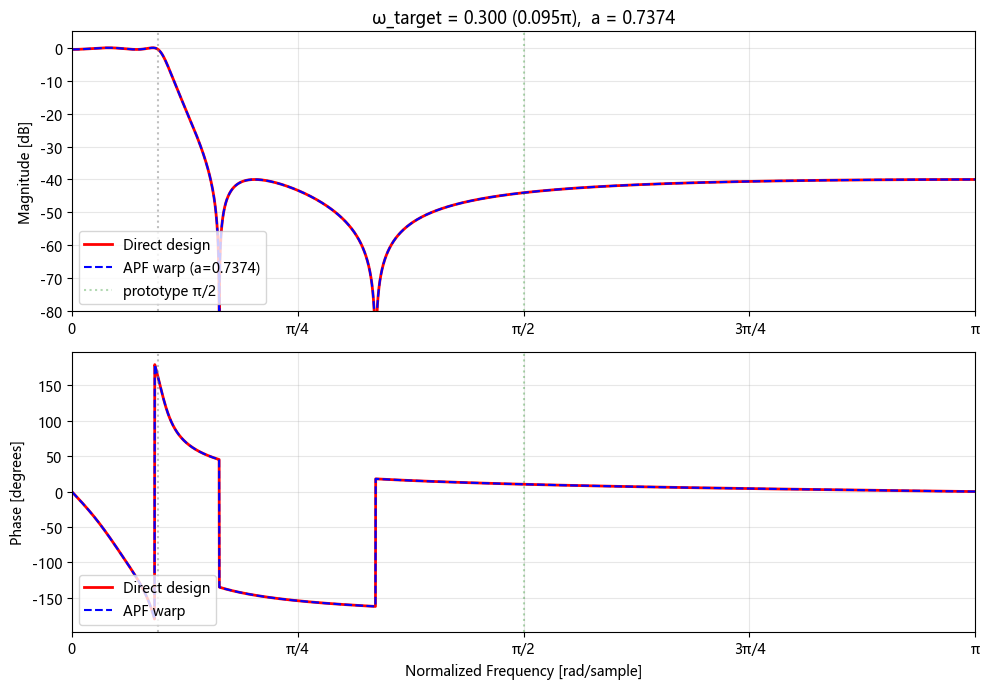

max|error| mag   = 1.48e-11 dB
max|error| phase = 5.52e-11 deg



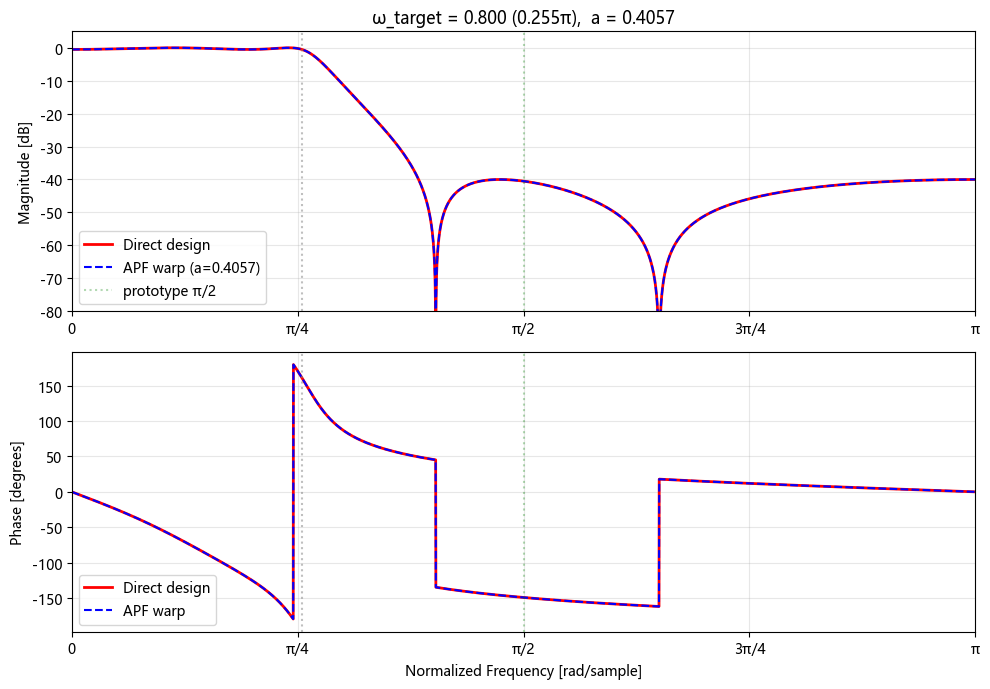

max|error| mag   = 3.27e-12 dB
max|error| phase = 3.50e-11 deg



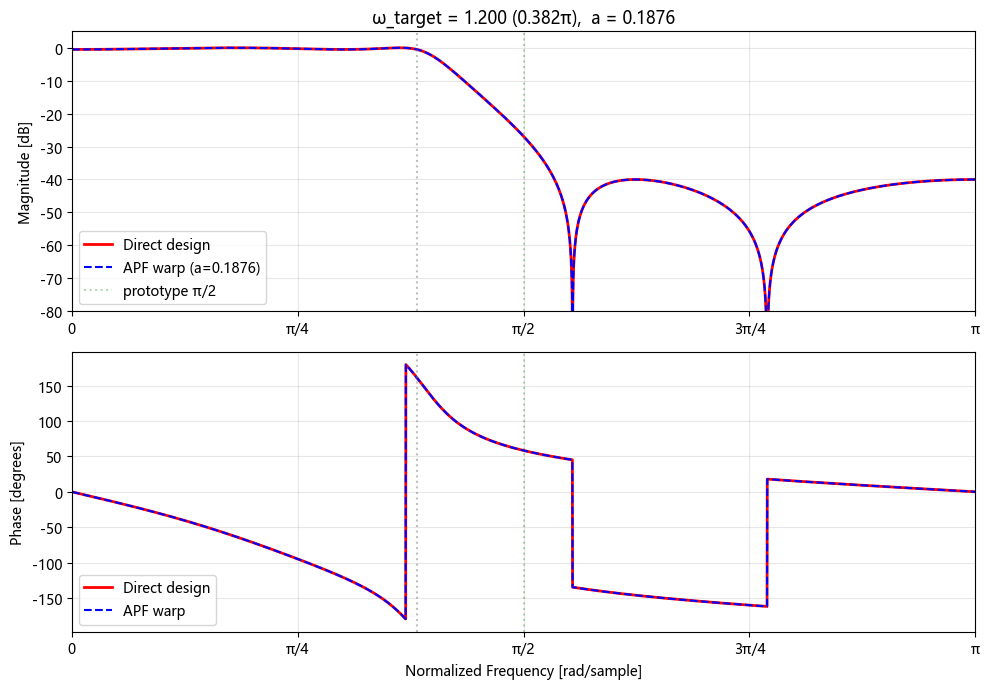

max|error| mag   = 3.69e-13 dB
max|error| phase = 3.70e-11 deg



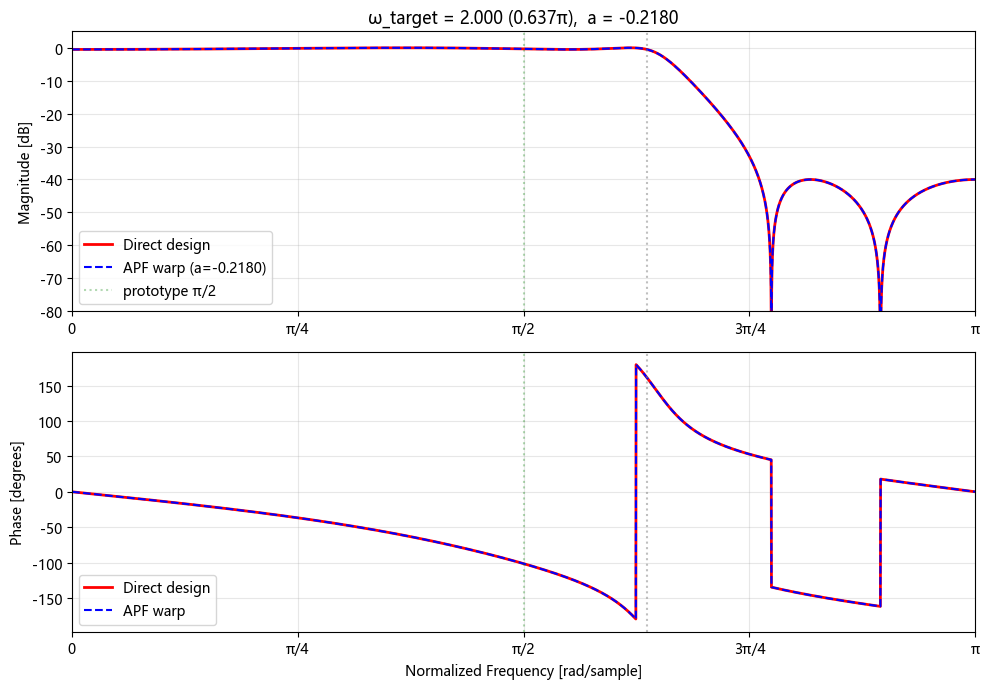

max|error| mag   = 1.93e-12 dB
max|error| phase = 2.00e-11 deg



In [21]:
# ============================================================
# 测试: 逆全通映射 G(y) 应用于真实椭圆滤波器
# 原型截止 ω_p = π/2, 扭曲到目标 ω_target
# 对比: 扭曲法 vs 直接法
# ============================================================


def apf_coeff_tan(omega_target):
    """全通系数 a = (1 - tan(ω/2)) / (1 + tan(ω/2))"""
    t = np.tan(omega_target / 2)
    return (1.0 - t) / (1.0 + t)


def inverse_apf_map(r, a):
    """逆全通映射: G(r) = (a + r) / (1 + a*r)"""
    return (a + r) / (1.0 + a * r)


def warp_zpk(z, p, g, a):
    """对 zpk 零/极点逐个做逆全通映射, 并补偿增益"""
    z_new = np.array([inverse_apf_map(zi, a) for zi in z])
    p_new = np.array([inverse_apf_map(pi, a) for pi in p])

    # 增益补偿: K = prod(1+aζ) / prod(1+ap)
    K = np.prod(1.0 + a * z) / np.prod(1.0 + a * p)
    g_new = g * float(np.real_if_close(K))
    return z_new, p_new, g_new


def compare_ellip_warp(omega_target, N=4, rp=0.5, rs=40.0, n_pts=4096):
    """
    对比直接设计 vs APF 扭曲法.
    原型固定截止于 ω_p = π/2.

    参数
    ----------
    omega_target : float
        目标截止频率 [0, π]
    N, rp, rs : int, float, float
        椭圆滤波器参数
    n_pts : int
        频率网格点数

    返回
    -------
    fig : matplotlib Figure
        幅频 + 相频双轴 Figure
    """
    omega_p = np.pi / 2
    w_grid = np.linspace(0.001, np.pi - 0.001, n_pts)

    # ---- 1. 原型滤波器 ----
    z_p, p_p, g_p = signal.ellip(N, rp, rs, omega_p / np.pi, output="zpk")

    # ---- 2. 全通系数 ----
    a_val = apf_coeff_tan(omega_target)

    # ---- 3. APF 扭曲法 ----
    z_w, p_w, g_w = warp_zpk(z_p, p_p, g_p, a_val)
    _, h_warp = signal.freqz_zpk(z_w, p_w, g_w, worN=w_grid, whole=False)

    # ---- 4. 直接设计法 ----
    z_d, p_d, g_d = signal.ellip(N, rp, rs, omega_target / np.pi, output="zpk")
    _, h_direct = signal.freqz_zpk(z_d, p_d, g_d, worN=w_grid, whole=False)

    # ---- 5. 绘制 ----
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 7))

    H_w_dB = 20 * np.log10(np.maximum(np.abs(h_warp), 1e-12))
    H_d_dB = 20 * np.log10(np.maximum(np.abs(h_direct), 1e-12))

    # 幅度
    ax_mag.plot(w_grid, H_d_dB, color="red", linewidth=2, label="Direct design")
    ax_mag.plot(
        w_grid,
        H_w_dB,
        color="blue",
        linewidth=1.5,
        linestyle="--",
        label=f"APF warp (a={a_val:.4f})",
    )
    ax_mag.axvline(omega_target, color="gray", linestyle=":", alpha=0.5)
    ax_mag.axvline(
        omega_p, color="green", linestyle=":", alpha=0.3, label="prototype π/2"
    )
    ax_mag.set_xlim(0, np.pi)
    ax_mag.set_ylim(-80, 5)
    ax_mag.set_ylabel("Magnitude [dB]")
    ax_mag.set_title(
        f"ω_target = {omega_target:.3f} ({omega_target / np.pi:.3f}π),  a = {a_val:.4f}"
    )
    ax_mag.grid(True, alpha=0.3)
    ax_mag.legend(loc="lower left")

    # 相位
    ax_phase.plot(
        w_grid,
        np.angle(h_direct, deg=True),
        color="red",
        linewidth=2,
        label="Direct design",
    )
    ax_phase.plot(
        w_grid,
        np.angle(h_warp, deg=True),
        color="blue",
        linewidth=1.5,
        linestyle="--",
        label=f"APF warp",
    )
    ax_phase.axvline(omega_target, color="gray", linestyle=":", alpha=0.5)
    ax_phase.axvline(omega_p, color="green", linestyle=":", alpha=0.3)
    ax_phase.set_xlim(0, np.pi)
    ax_phase.set_ylabel("Phase [degrees]")
    ax_phase.set_xlabel("Normalized Frequency [rad/sample]")
    ax_phase.grid(True, alpha=0.3)
    ax_phase.legend(loc="lower left")

    for ax in (ax_mag, ax_phase):
        ax.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
        ax.set_xticklabels(["0", "π/4", "π/2", "3π/4", "π"])

    plt.tight_layout()
    plt.show()

    # 误差报告
    max_err_mag = np.max(np.abs(H_w_dB - H_d_dB))
    max_err_phase = np.max(
        np.abs(np.angle(h_warp, deg=True) - np.angle(h_direct, deg=True))
    )
    print(f"max|error| mag   = {max_err_mag:.2e} dB")
    print(f"max|error| phase = {max_err_phase:.2e} deg")

    return fig


# ============================================================
# 演示: 测试多个目标截止频率
# ============================================================

print("=" * 60)
print("演示: 多个目标截止频率")
print("=" * 60)
print()

for wt in [0.3, 0.8, 1.2, 2.0]:
    compare_ellip_warp(wt)
    print()

# lowpass原型到高通
映射的全通滤波器与上述保持相同  
额外的步骤，在将全通滤波器带入H(z)之前，需要先使用H(-z)转换为pi/2的高通原型滤波器  
直接简化为H(-H'(z))  

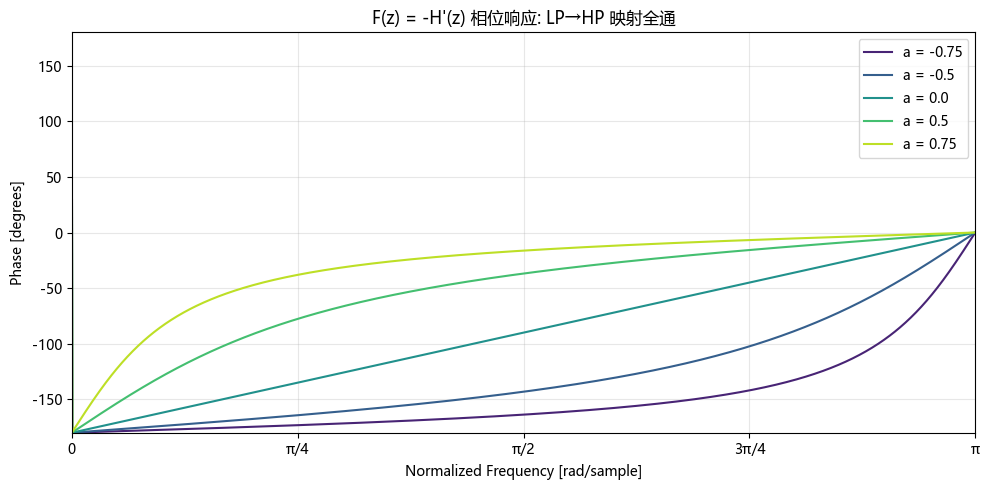

F(z) = -H'(z) = -(z - a)/(1 - a z)
  零点 z = a    (|a|<1 时在内)
  极点 z = 1/a  (|a|<1 时在外)  → 不稳定
  效果: DC↔Nyquist 翻转, LP→HP

目标2: 求解 F(e^{jω}) = j 中的 a
给定 z = e^{jω}, 解 a =


(z + I)/(I*z + 1)


代入 z = e^{jω}:
  a = - \frac{\cos{\left(w \right)}}{\sin{\left(w \right)} - 1}

目标3: H(-H'(z)) 零极点映射
  F(z) = -(z - a)/(1 - a z)
  F^{-1}(y) = (a - y)/(1 - a y)

F^{-1}(y) =


(-a + y)/(a*y - 1)


  ζ* = F^-1(ζ) = \frac{- a + ζ}{a ζ - 1}
  p*  = F^-1(p)  = \frac{- a + p}{a p - 1}

验证: F(ζ*) = ζ = ζ?  True

增益因子 K 推导
F(z)-ζ 的分子因式分解:
  F(z)-ζ = - a z ζ - a + z + ζ / a z - 1
  提取公因子后的分子: z系数 = 1

增益因子 K:
  K = g · ∏(aζ-1)/∏(ap-1)
  K = \frac{\left(a ζ - 1\right) \left(a \overline{ζ} - 1\right)}{\left(a p - 1\right) \left(a \overline{p} - 1\right)}

其中 ζ* = (a-ζ)/(1-aζ), p* = (a-p)/(1-ap)
且 H(F(z)) = K · (z-ζ*)(z-ζ̄*)/(z-p*)(z-p̄*)


In [51]:
# ============================================================
# 正确映射: 使用 -H'(z) 实现低通→高通
# F(z) = -H'(z) = -(1 - a z^{-1})/(z^{-1} - a) = (a z^{-1} - 1)/(z^{-1} - a)
#      = -(z - a)/(1 - a z)
#
# 性质: DC → Nyquist, Nyquist → DC (频率轴翻转)
# 结果: LP 原型 π/2 → HP
# ============================================================


# ============================================================
# 目标1: F(z) = -H'(z) 的相位响应
# ============================================================

a_vals = [-0.75, -0.5, 0.0, 0.5, 0.75]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(a_vals)))

fig_f, ax_f = plt.subplots(figsize=(10, 5))

for a, c in zip(a_vals, colors):
    # -H'(z) = (a z^{-1} - 1)/(z^{-1} - a)  →  b=[-1, a], a_coeffs=[-a, 1]
    w, h = signal.freqz([-1.0, a], [-a, 1.0], worN=2048)
    ax_f.plot(w, np.angle(h, deg=True), color=c, linewidth=1.5, label=f"a = {a}")

ax_f.set_xlim(0, np.pi)
ax_f.set_ylim(-180, 180)
ax_f.set_xlabel("Normalized Frequency [rad/sample]")
ax_f.set_ylabel("Phase [degrees]")
ax_f.set_title("F(z) = -H'(z) 相位响应: LP→HP 映射全通")
ax_f.grid(True, alpha=0.3)
ax_f.legend(loc="best")
ax_f.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax_f.set_xticklabels(["0", "π/4", "π/2", "3π/4", "π"])

plt.tight_layout()
plt.show()

print("F(z) = -H'(z) = -(z - a)/(1 - a z)")
print("  零点 z = a    (|a|<1 时在内)")
print("  极点 z = 1/a  (|a|<1 时在外)  → 不稳定")
print("  效果: DC↔Nyquist 翻转, LP→HP")
print()

# ============================================================
# 目标2: 求解 F(e^{jω}) = j 时的 a
# ============================================================
print("=" * 60)
print("目标2: 求解 F(e^{jω}) = j 中的 a")
print("=" * 60)

a_sym, z = sp.symbols("a z", real=False)
w_sym = sp.symbols("w", real=True)

# F(z) = -H'(z) = -(1 - a/z)/(1/z - a)
F_expr = -(1 - a_sym / z) / (1 / z - a_sym)
sol_a = sp.solve(sp.Eq(F_expr, sp.I), a_sym)
a_expr = sp.simplify(sol_a[0])
print("给定 z = e^{jω}, 解 a =")
display(a_expr)
print()

a_of_w = sp.simplify(a_expr.subs(z, sp.exp(sp.I * w_sym)))
a_real = sp.simplify(sp.re(sp.expand_complex(a_of_w)))
print("代入 z = e^{jω}:")
print(f"  a = {sp.latex(a_real)}")
print()

# ============================================================
# 目标3: H(-H'(z)) 零极点映射
# LP 原型 H(z) → H(F(z)) 直接为高通
# ζ* = F^{-1}(ζ),  F^{-1}(y) = (a - y)/(1 - a y)
# ============================================================
print("=" * 60)
print("目标3: H(-H'(z)) 零极点映射")
print("=" * 60)
print("  F(z) = -(z - a)/(1 - a z)")
print("  F^{-1}(y) = (a - y)/(1 - a y)")
print()

zeta, p_val = sp.symbols("ζ p", real=False)

y = sp.Symbol("y")
eq_finv = sp.Eq(-(z - a_sym) / (1 - a_sym * z), y)
Finv = sp.solve(eq_finv, z)[0]
print("F^{-1}(y) =")
display(Finv)
print()

zeta_star = sp.simplify(Finv.subs(y, zeta))
p_star = sp.simplify(Finv.subs(y, p_val))
print(f"  ζ* = F^{-1}(ζ) = {sp.latex(zeta_star)}")
print(f"  p*  = F^{-1}(p)  = {sp.latex(p_star)}")
print()

# 验证
check = sp.simplify(-(zeta_star - a_sym) / (1 - a_sym * zeta_star))
print(f"验证: F(ζ*) = {sp.latex(check)} = ζ?  {sp.simplify(check - zeta) == 0}")
print()

# ============================================================
# 增益因子推导: F(z)-ζ 的因式分解
# F(z)-ζ = -(z-a)/(1-az) - ζ
#        = [z(aζ-1) + (a-ζ)] / (1-az)
#        = (aζ-1)(z-ζ*)/(1-az)
# 所以 H(F(z)) = K * ∏(z-ζ*)/∏(z-p*)
# 其中 K = g * ∏(aζ-1)/∏(ap-1)
# ============================================================
print("=" * 60)
print("增益因子 K 推导")
print("=" * 60)

# 因式分解 F(z) - ζ
F_expr = -(z - a_sym) / (1 - a_sym * z)
diff_zeta = sp.simplify(F_expr - zeta)
num, den = sp.fraction(diff_zeta)

# 提取因子 (aζ-1)
K_factor_zeta = sp.simplify(sp.collect(num, z).coeff(z, 1))
print("F(z)-ζ 的分子因式分解:")
print(f"  F(z)-ζ = {sp.latex(sp.factor(num))} / {sp.latex(den)}")
print(f"  提取公因子后的分子: z系数 = {sp.latex(sp.simplify(K_factor_zeta))}")
print()

# 手动展示完整的因子分解形式
zeta_bar = sp.conjugate(zeta)
p_bar = sp.conjugate(p_val)

# 增益因子 K = ∏(aζ-1)∏(aζ̄-1) / ∏(ap-1)∏(ap̄-1)
K_num_expr = (a_sym * zeta - 1) * (a_sym * zeta_bar - 1)
K_den_expr = (a_sym * p_val - 1) * (a_sym * p_bar - 1)
K_expr = sp.simplify(K_num_expr / K_den_expr)
print("增益因子 K:")
print(f"  K = g · ∏(aζ-1)/∏(ap-1)")
print(f"  K = {sp.latex(sp.simplify(K_num_expr / K_den_expr))}")
print()
print("其中 ζ* = (a-ζ)/(1-aζ), p* = (a-p)/(1-ap)")
print("且 H(F(z)) = K · (z-ζ*)(z-ζ̄*)/(z-p*)(z-p̄*)")

演示: -H'(z) 低通→高通 频率扭曲



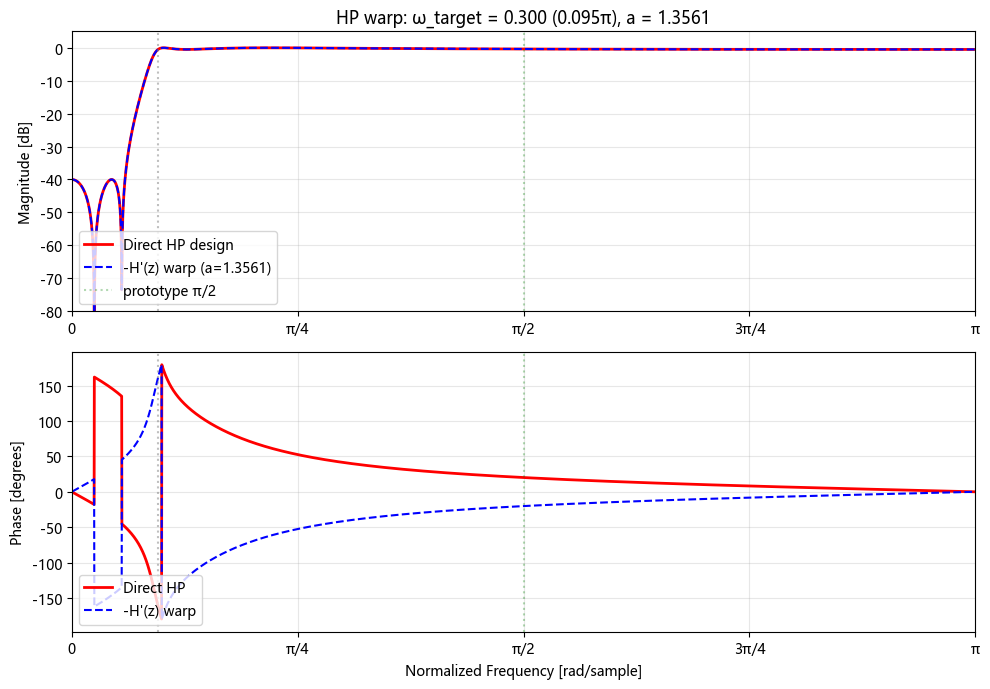

max|error| mag   = 2.70e-12 dB
max|error| phase = 3.59e+02 deg



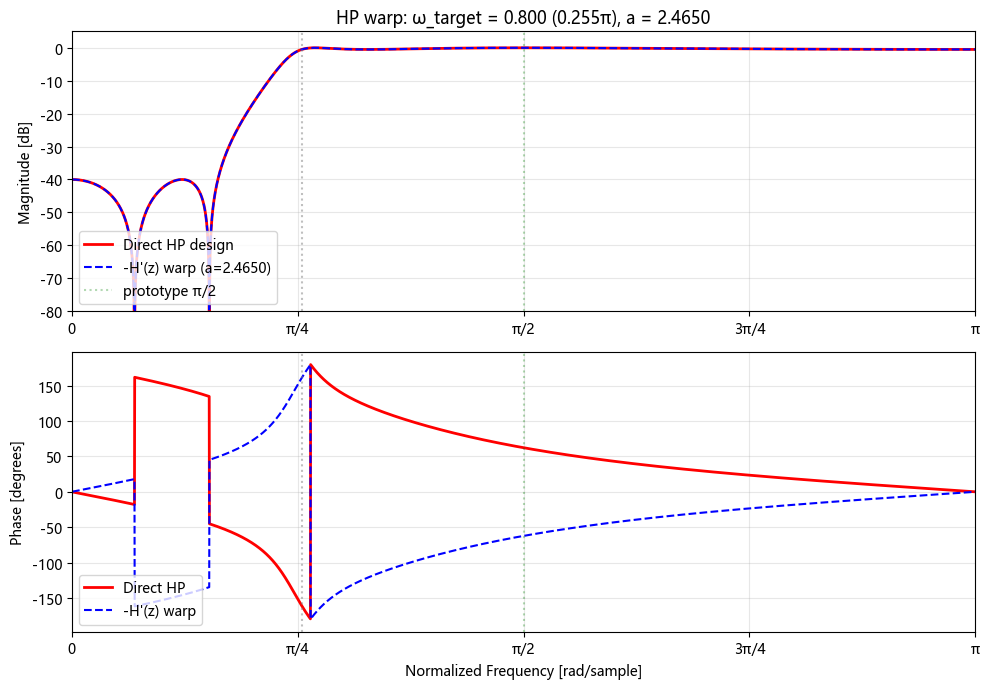

max|error| mag   = 4.92e-12 dB
max|error| phase = 3.60e+02 deg



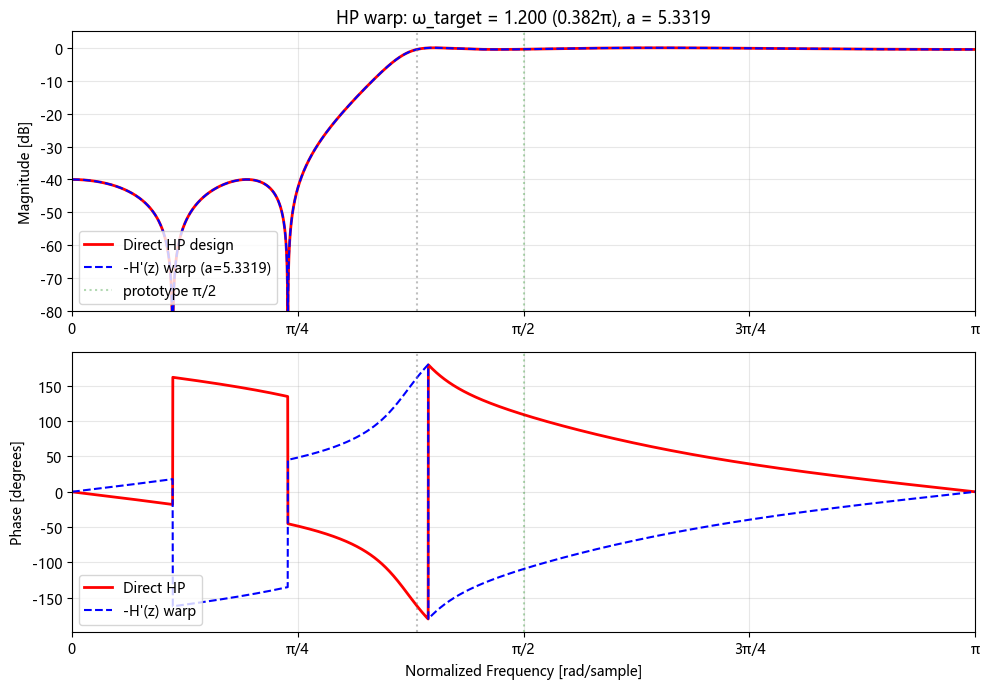

max|error| mag   = 3.35e-12 dB
max|error| phase = 3.60e+02 deg



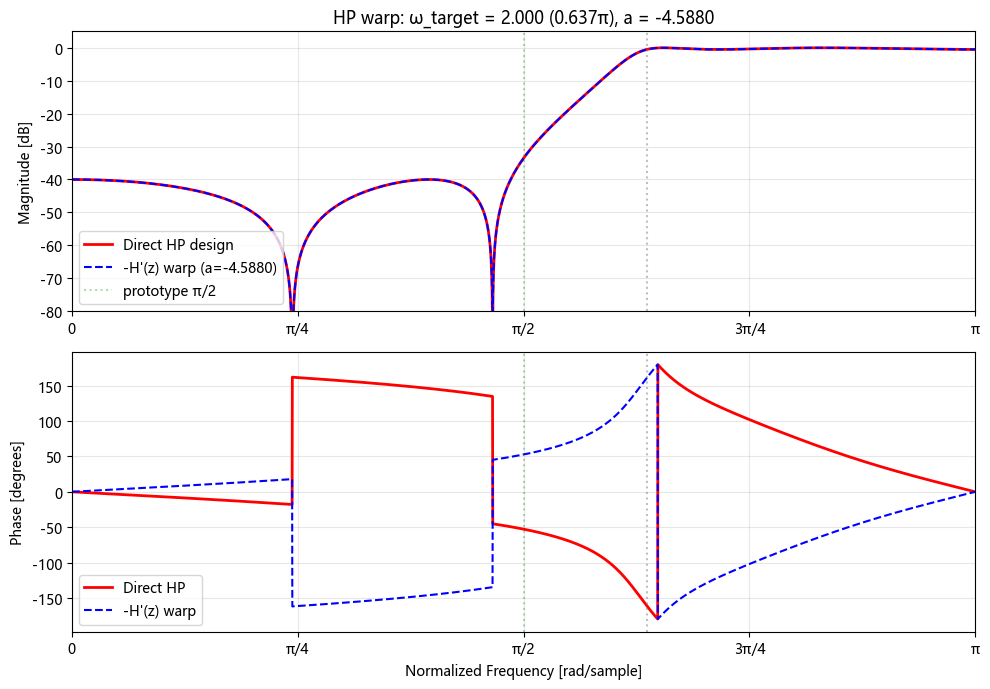

max|error| mag   = 7.73e-12 dB
max|error| phase = 3.60e+02 deg



In [56]:
# ============================================================
# 验证: H(z) → H(-H'(z)) 低通→高通 (类似 cell12 方式)
#
# F(z) = -H'(z) = -(z - a)/(1 - a z)
# F(e^{jω}) = j  →  a = (j + z)/(1 + j z)  (z = e^{jω})
# ζ* = F^{-1}(ζ) = (a - ζ)/(1 - a ζ)
# ============================================================


# ============================================================
# 独立函数 (类似 cell12)
# ============================================================


def apf_coeff_hp(omega_target):
    """全通系数 a: 由 F(e^{jω}) = j 导出
    a = (j + e^{jω})/(1 + j e^{jω}) = cos(ω)/(1 - sin(ω))
    """
    return np.cos(omega_target) / (1.0 - np.sin(omega_target))


def Finv_map(y, a):
    """F^{-1}(y) = (a - y)/(1 - a y)"""
    return (a - y) / (1.0 - a * y)


def warp_zpk_hp(z, p, g, a):
    """对 zpk 零/极点做 F^{-1} 映射 + 增益修正
    由 F(z)-ζ = (aζ-1)(z-ζ*)/(1-az) 得增益因子 K = prod(aζ-1)/prod(ap-1)
    """
    z_new = np.array([Finv_map(zi, a) for zi in z])
    p_new = np.array([Finv_map(pi, a) for pi in p])

    # 增益修正: K = prod(a*ζ - 1) / prod(a*p - 1)
    K = np.prod(a * z - 1.0) / np.prod(a * p - 1.0)
    g_new = g * float(np.real_if_close(K))
    return z_new, p_new, g_new


def compare_ellip_warp_hp(omega_target, N=4, rp=0.5, rs=40.0, n_pts=4096):
    """
    对比直接高通设计 vs -H'(z) 扭曲法.
    原型固定截止于 ω_p = π/2.
    """
    omega_p = np.pi / 2
    w_grid = np.linspace(0.001, np.pi - 0.001, n_pts)

    # 原型低通
    z_p, p_p, g_p = signal.ellip(N, rp, rs, omega_p / np.pi, output="zpk")

    # 全通系数 (由目标截止频率计算)
    a_val = apf_coeff_hp(omega_target)

    # -H'(z) 扭曲法
    z_w, p_w, g_w = warp_zpk_hp(z_p, p_p, g_p, a_val)
    _, h_warp = signal.freqz_zpk(z_w, p_w, g_w, worN=w_grid, whole=False)

    # 直接高通设计
    z_d, p_d, g_d = signal.ellip(
        N, rp, rs, omega_target / np.pi, btype="high", output="zpk"
    )
    _, h_direct = signal.freqz_zpk(z_d, p_d, g_d, worN=w_grid, whole=False)

    # 绘制
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 7))

    H_w_dB = 20 * np.log10(np.maximum(np.abs(h_warp), 1e-12))
    H_d_dB = 20 * np.log10(np.maximum(np.abs(h_direct), 1e-12))

    ax_mag.plot(w_grid, H_d_dB, color="red", linewidth=2, label="Direct HP design")
    ax_mag.plot(
        w_grid,
        H_w_dB,
        color="blue",
        linewidth=1.5,
        ls="--",
        label=f"-H'(z) warp (a={a_val:.4f})",
    )
    ax_mag.axvline(omega_target, color="gray", ls=":", alpha=0.5)
    ax_mag.axvline(omega_p, color="green", ls=":", alpha=0.3, label="prototype π/2")
    ax_mag.set_xlim(0, np.pi)
    ax_mag.set_ylim(-80, 5)
    ax_mag.set_ylabel("Magnitude [dB]")
    ax_mag.set_title(
        f"HP warp: ω_target = {omega_target:.3f} ({omega_target / np.pi:.3f}π), a = {a_val:.4f}"
    )
    ax_mag.grid(True, alpha=0.3)
    ax_mag.legend(loc="lower left")

    ax_phase.plot(
        w_grid,
        np.angle(h_direct, deg=True),
        color="red",
        linewidth=2,
        label="Direct HP",
    )
    ax_phase.plot(
        w_grid,
        np.angle(h_warp, deg=True),
        color="blue",
        linewidth=1.5,
        ls="--",
        label="-H'(z) warp",
    )
    ax_phase.axvline(omega_target, color="gray", ls=":", alpha=0.5)
    ax_phase.axvline(omega_p, color="green", ls=":", alpha=0.3)
    ax_phase.set_xlim(0, np.pi)
    ax_phase.set_ylabel("Phase [degrees]")
    ax_phase.set_xlabel("Normalized Frequency [rad/sample]")
    ax_phase.grid(True, alpha=0.3)
    ax_phase.legend(loc="lower left")

    for ax in (ax_mag, ax_phase):
        ax.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
        ax.set_xticklabels(["0", "π/4", "π/2", "3π/4", "π"])

    plt.tight_layout()
    plt.show()

    max_err_mag = np.max(np.abs(H_w_dB - H_d_dB))
    max_err_phase = np.max(
        np.abs(np.angle(h_warp, deg=True) - np.angle(h_direct, deg=True))
    )
    print(f"max|error| mag   = {max_err_mag:.2e} dB")
    print(f"max|error| phase = {max_err_phase:.2e} deg")
    return fig


# ============================================================
# 演示: 多个目标截止频率
# ============================================================
print("=" * 60)
print("演示: -H'(z) 低通→高通 频率扭曲")
print("=" * 60)
print()

for wt in [0.3, 0.8, 1.2, 2.0]:
    compare_ellip_warp_hp(wt)
    print()

因垂丝汀，在不同N下hp的符号都加了一个负号